In [1]:
import asyncio
import pandas as pd
import matplotlib.pyplot as plt
from src.technical_analysis import TradeAnalysis
from src.helper_functions import ExcelOperations

class Metrics:
    KEY_METRICS = None

class Trades:
    def __init__(self):    
        self.check_loop()
    
        
    def check_loop(self):
        try:
            loop = asyncio.get_running_loop()
        except RuntimeError:  # 'RuntimeError: There is no current event loop...'
            loop = None
        
        if loop and loop.is_running():
            print('Async event loop already running. Adding coroutine to the event loop.')
            tsk = loop.create_task(run_trade_analysis())
            # ^-- https://docs.python.org/3/library/asyncio-task.html#task-object
            # Optionally, a callback function can be executed when the coroutine completes
            tsk.add_done_callback(
                lambda t: print(f'Task done with result={t.result()}  << return val of main()'))
        else:
            print('Starting new event loop')
            result = asyncio.run(run_trade_analysis())
            print(result)


async def run_trade_analysis():
    trade_analysis = TradeAnalysis()
    # await asyncio.sleep(1)
    indicators = trade_analysis.set_indicators()
    # test = trade_analysis
    # print(test)
    # absolute_path = ExcelOperations.get_abs_path()

    await asyncio.sleep(1)
    absolute_path = ExcelOperations.get_abs_path()
    # get the dataframe for key metrics
    df_key_metrics = pd.read_excel(absolute_path, sheet_name="key_metrics")
    df_price = pd.read_excel(absolute_path, sheet_name="stock_price")
    # get the latest key metric for each symbol
    latest_key_metric = df_key_metrics.groupby('symbol').first().sort_values('date')[indicators]
    metrics = pd.merge(latest_key_metric, df_price, on="symbol", how="left")
    Metrics.KEY_METRICS = metrics
    return 'check'
    # compare price with graham number and use pe ratio to determine whether stock is undervalued

Trades()

ModuleNotFoundError: No module named 'src'

In [40]:
print(Metrics.KEY_METRICS.head())

      symbol     peRatio  ...  sharesOutstanding   timestamp
0    SLCL.TA    0.000000  ...            1894442  1703601737
1    0052.HK  372.784809  ...          129553000  1703231024
2  300829.SZ   68.444442  ...          180655000  1703574280
3    1208.HK    0.000000  ...         8656050000  1703232483
4  002527.SZ    0.000000  ...          661281000  1703574297

[5 rows x 30 columns]


In [42]:
# iterating the columns
for col in Metrics.KEY_METRICS.columns:
    print(col)

symbol
peRatio
debtToEquity
roic
roe
grahamNumber
dividendYield
payoutRatio
Unnamed: 0
name
price
changesPercentage
change
dayLow
dayHigh
yearHigh
yearLow
marketCap
priceAvg50
priceAvg200
exchange
volume
avgVolume
open
previousClose
eps
pe
earningsAnnouncement
sharesOutstanding
timestamp


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'SLCL.TA'),
  Text(1, 0, '0052.HK'),
  Text(2, 0, '300829.SZ'),
  Text(3, 0, '1208.HK'),
  Text(4, 0, '002527.SZ'),
  Text(5, 0, '002579.SZ'),
  Text(6, 0, '0J3H.L'),
  Text(7, 0, '0JYA.L'),
  Text(8, 0, '603618.SS'),
  Text(9, 0, '605555.SS'),
  Text(10, 0, '6638.T'),
  Text(11, 0, '8540.HK'),
  Text(12, 0, 'HMBL'),
  Text(13, 0, 'MELG.OL'),
  Text(14, 0, 'RWE.DE'),
  Text(15, 0, 'SPYL.NS')])

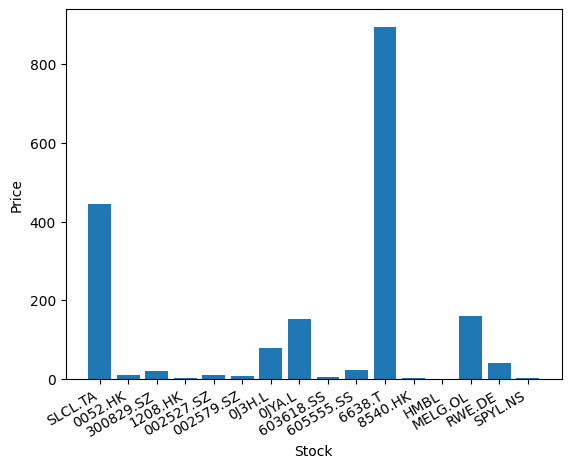

In [73]:
x = Metrics.KEY_METRICS['symbol']
y = Metrics.KEY_METRICS['price']
# Plot the histogram with specific values on the x-axis
# plt.bar(x, y, color='skyblue', edgecolor='black', width=1)

fig, ax = plt.subplots()
# Set labels for the x-axis and y-axis
plt.xlabel('Stock')
plt.ylabel('Price')
ax.bar(x,y)
plt.xticks(rotation=30, ha='right')


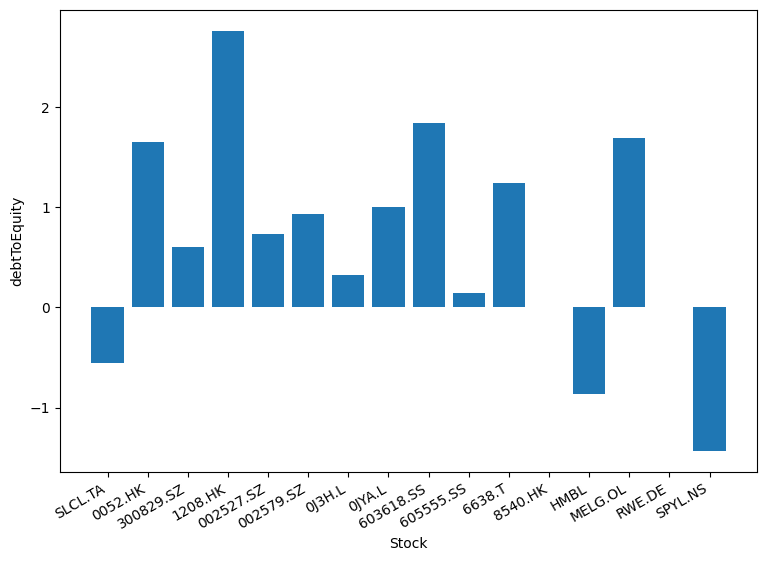

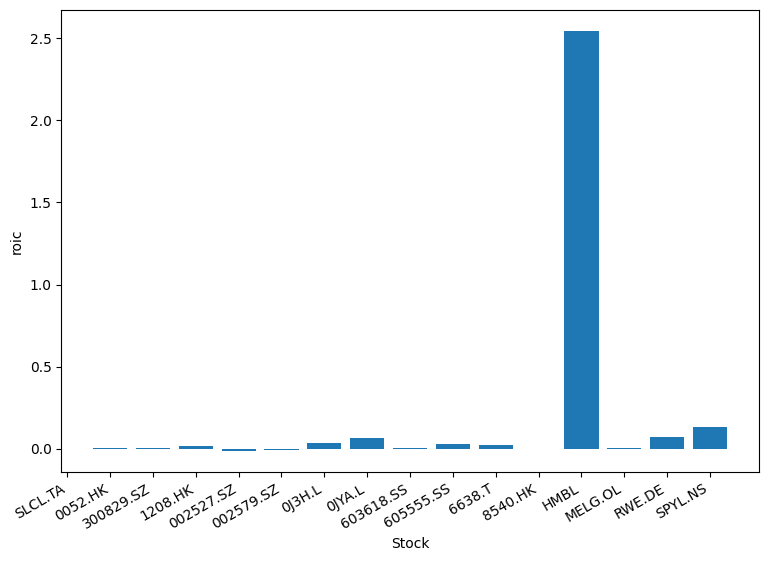

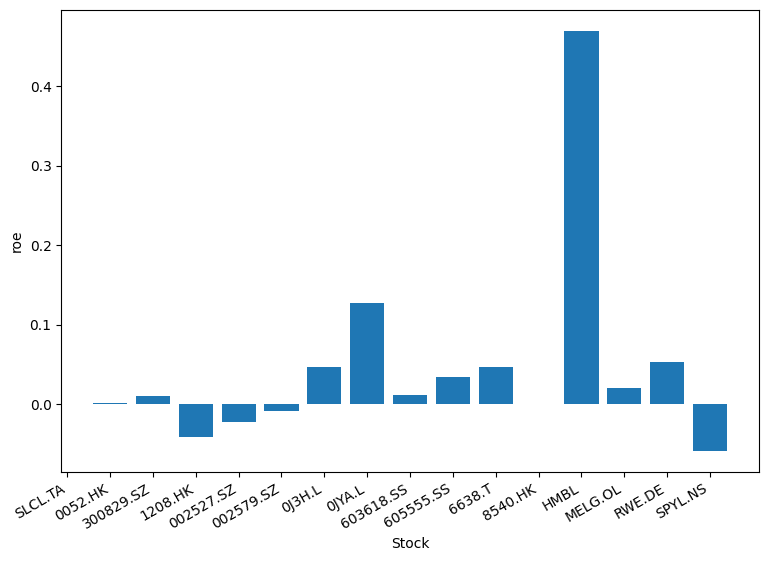

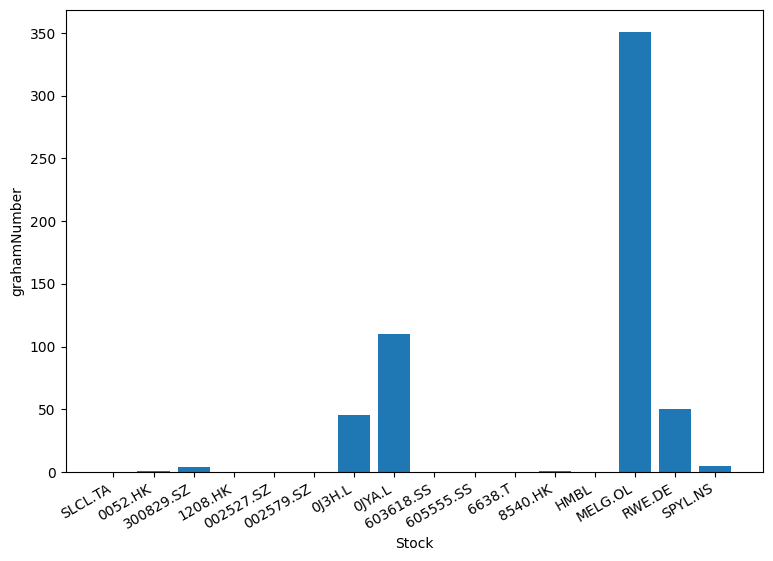

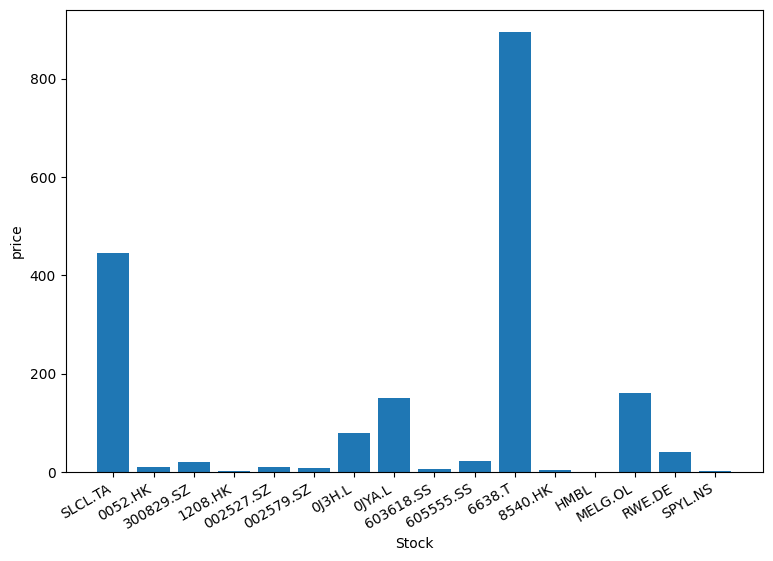

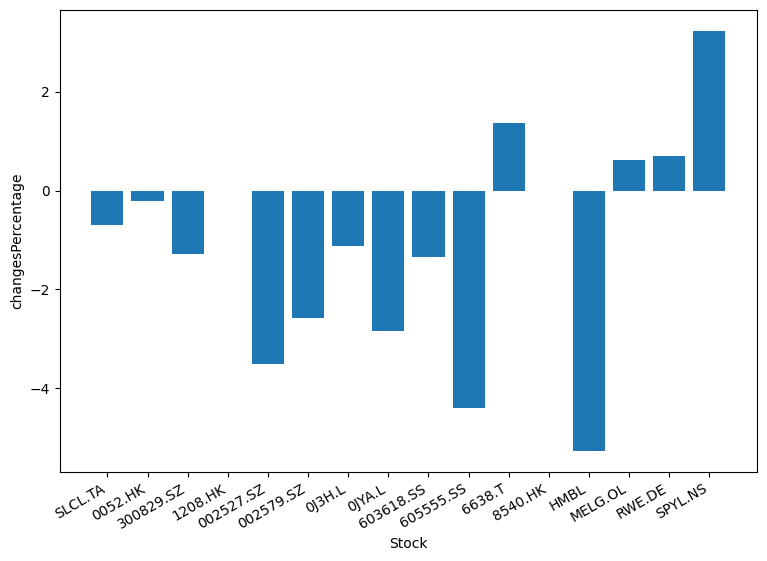

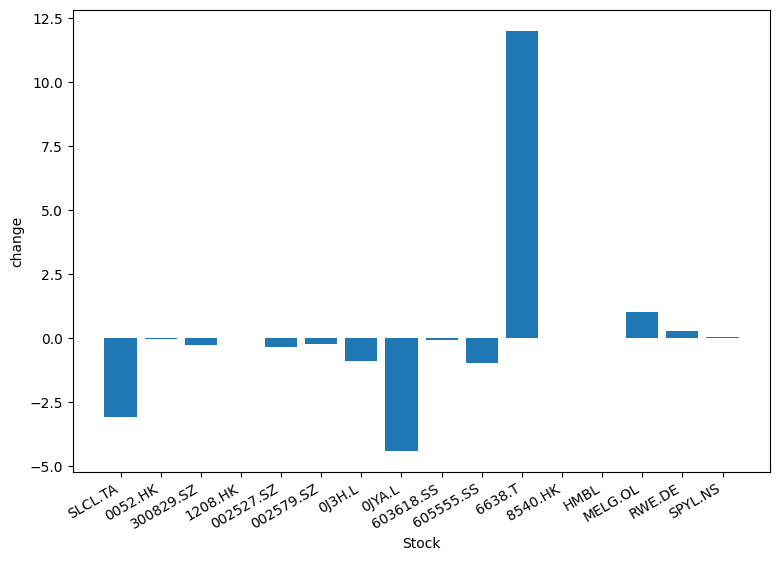

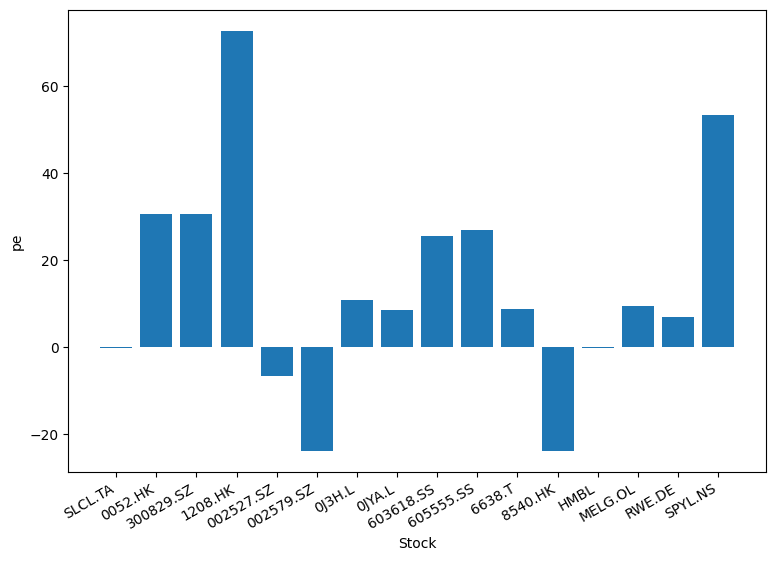

In [84]:
def display_metrics():
    x = Metrics.KEY_METRICS['symbol']
    required_metrics = ['pe', 'debtToEquity', 'roic', 'roe', 'grahamNumber', 'price', 'changesPercentage', 'change']

    for col in Metrics.KEY_METRICS.columns:
        if col not in required_metrics:
            continue
        fig, ax = plt.subplots(figsize=(9,6))
        # Set labels for the x-axis and y-axis
        plt.xlabel('Stock')
        plt.ylabel(col)
        y = Metrics.KEY_METRICS[col]
        ax.bar(x,y)
        plt.xticks(rotation=30, ha='right')

display_metrics()
        

In [76]:
len(Metrics.KEY_METRICS)

16